In [8]:
import networkx as nx
import json
import pandas as pd
import os
from tqdm import tqdm

def load_json(file_path):
    with open(file_path) as f:
        data = json.load(f)
    return data

In [6]:
data_path = '/Users/ahmed/Desktop/msc-24/ECHR/echr-minimal'
files = os.listdir(data_path)

In [17]:

# Initialize the graph
G = nx.DiGraph()

In [18]:
def add_case_node_to_graph(case):
    # Add the case document as a node
    G.add_node(
        case["itemid"],
        label=case["docname"],
        type="Judgment",
        appno=case["appno"],
        importance=case["importance"],
        judgementdate=case["judgementdate"],
        rank=case["rank"]
    )

    # Add the application node
    appno = case["appno"]
    if ';' in appno:
        appnos = appno.split(";")
        for appno in appnos:
            if not G.has_node(appno):
                G.add_node(appno, label=f"Application {appno}", type="Application")
            G.add_edge(appno, case["itemid"], relationship="consolidated_into")  # Link the document to its application
    else:    
        if not G.has_node(appno):
            G.add_node(appno, label=f"Application {appno}", type="Application") 
        G.add_edge(appno, case["itemid"], relationship="has_document") # Link the document to its application

    # Add article nodes
    for article in case["article"]:
        if not G.has_node(article):
            G.add_node(article, label=f"Article {article}", type="Article")
        G.add_edge(case["itemid"], article, relationship="violates")


    # add cited applications
    for appno in case["extractedappno"]:
        if not G.has_node(appno):
            G.add_node(appno, label=f"Application {appno}", type="Application")
        G.add_edge(appno, case["itemid"], relationship="cites")


In [24]:
for file in tqdm(files):
    if file.endswith('.json'):
        data = load_json(os.path.join(data_path, file))
        add_case_node_to_graph(data)

100%|██████████| 16096/16096 [00:03<00:00, 5194.02it/s]


In [32]:
def get_articles_violated_by_case(itemid):
    return [
        target for source, target, data in G.edges(data=True)
        if source == itemid and data["relationship"] == "violates"
    ]

# Example usage
itemid = "001-57416"
violated_articles = get_articles_violated_by_case(itemid)
print(f"Articles violated by case {itemid}: {violated_articles}")


Articles violated by case 001-57416: ['41', '3', '8', '14', '13']


In [35]:
def get_documents_for_application(appno):
    return [
        target for source, target, data in G.edges(data=True)
        if source == appno and data["relationship"] in ["consolidated_into", "has_document"]
    ]

# Example usage
appno = "9214/80"
documents = get_documents_for_application(appno)
print(f"Documents linked to application {appno}: {documents}")


Documents linked to application 9214/80: []


In [36]:
def get_cited_applications(itemid):
    return [
        source for source, target, data in G.edges(data=True)
        if target == itemid and data["relationship"] == "cites"
    ]

# Example usage
itemid = "001-57416"
cited_appnos = get_cited_applications(itemid)
print(f"Applications cited by case {itemid}: {cited_appnos}")

Applications cited by case 001-57416: ['9214/80', '9473/81', '9474/81']


In [37]:
def rank_by_citations(node_type):
    return sorted(
        [(node, G.in_degree(node)) for node, data in G.nodes(data=True) if data["type"] == node_type],
        key=lambda x: x[1],
        reverse=True
    )

# Example usage
top_cited_appnos = rank_by_citations("Application")
print("Top cited applications:", top_cited_appnos)

top_cited_judgments = rank_by_citations("Judgment")
print("Top cited judgments:", top_cited_judgments)

Top cited applications: [('27243/95', 0), ('23657/94', 0), ('24746/94', 0), ('21890/03', 0), ('13425/02', 0), ('24888/94', 0), ('37641/97', 0), ('92/03', 0), ('51895/99', 0), ('26772/95', 0), ('46702/99', 0), ('6544/05', 0), ('31330/02', 0), ('17584/04', 0), ('45219/06', 0), ('30210/96', 0), ('24139/20', 0), ('18357/91', 0), ('41183/02', 0), ('51227/16', 0), ('30754/04', 0), ('166/02', 0), ('65/02', 0), ('40016/98', 0), ('24790/04', 0), ('28114/95', 0), ('7170/02', 0), ('55955/00', 0), ('5977/03', 0), ('28883/95', 0), ('32967/96', 0), ('59548/00', 0), ('71463/01', 0), ('56679/00', 0), ('72286/01', 0), ('9852/03', 0), ('13413/04', 0), ('77688/01', 0), ('45305/99', 0), ('46477/99', 0), ('11562/05', 0), ('26614/95', 0), ('36813/97', 0), ('64886/01', 0), ('23788/06', 0), ('77690/01', 0), ('70985/01', 0), ('30979/96', 0), ('31107/96', 0), ('43577/98', 0), ('43579/98', 0), ('47152/06', 0), ('40/33', 0), ('57325/00', 0), ('25702/94', 0), ('32541/08', 0), ('43441/08', 0), ('56581/00', 0), ('27

In [38]:
def get_key_judgments(importance_level):
    return [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    ]

# Example usage
key_judgments = get_key_judgments("1")  # Importance level "2"
print("Key judgments:", key_judgments)


Key judgments: ['001-60310', '001-161822', '001-59587', '001-69424', '001-71444', '001-58379', '001-96585', '001-59211', '001-177299', '001-60486', '001-187188', '001-159324', '001-81352', '001-72680', '001-61805', '001-67482', '001-169053', '001-59616', '001-58841', '001-161530', '001-189641', '001-67928', '001-61055', '001-58292', '001-58338', '001-60644', '001-58912', '001-61686', '001-142196', '001-87156', '001-108690', '001-59591', '001-170663', '001-59207', '001-159762', '001-58800', '001-194618', '001-67457', '001-72205', '001-58251', '001-59339', '001-77791', '001-214330', '001-127055', '001-97879', '001-76495', '001-59102', '001-61184', '001-61887', '001-61868', '001-96100', '001-67816', '001-69672', '001-97087', '001-61757', '001-219943', '001-59051', '001-78425', '001-70445', '001-213908', '001-70853', '001-58586', '001-58752', '001-61829', '001-126982', '001-71983', '001-61080', '001-59456', '001-58494', '001-60941', '001-61716', '001-60170', '001-75688', '001-60936', '001-

In [39]:
def find_citation_paths(source_appno, target_appno):
    return list(nx.all_simple_paths(G, source=source_appno, target=target_appno))

# Example usage
source_appno = "9214/80"
target_appno = "9473/81"
citation_paths = find_citation_paths(source_appno, target_appno)
print(f"Citation paths from {source_appno} to {target_appno}: {citation_paths}")

Citation paths from 9214/80 to 9473/81: []


In [40]:
from datetime import datetime

def judgments_per_year():
    years = {}
    for node, data in G.nodes(data=True):
        if data["type"] == "Judgment":
            year = datetime.strptime(data["judgementdate"], "%d/%m/%Y").year
            years[year] = years.get(year, 0) + 1
    return years

# Example usage
judgment_trends = judgments_per_year()
print("Judgments per year:", judgment_trends)

Judgments per year: {2002: 212, 2007: 882, 2009: 972, 2022: 907, 2016: 729, 2010: 868, 2004: 339, 2021: 825, 2023: 632, 2006: 861, 1995: 37, 2003: 295, 2014: 598, 2001: 187, 2005: 538, 2015: 590, 2008: 870, 2012: 758, 2017: 863, 2018: 818, 2020: 620, 1993: 38, 2011: 709, 2013: 618, 1999: 79, 1983: 13, 1997: 70, 1982: 10, 2019: 620, 1981: 5, 1996: 51, 2000: 155, 1969: 2, 1998: 86, 1985: 7, 1991: 30, 1992: 30, 1986: 15, 1990: 22, 1968: 3, 1994: 40, 1988: 15, 1989: 19, 1987: 18, 1984: 14, 1980: 3, 1976: 6, 1975: 2, 1978: 5, 1979: 4, 1971: 2, 1972: 1, 1974: 1, 1970: 1, 1961: 1}


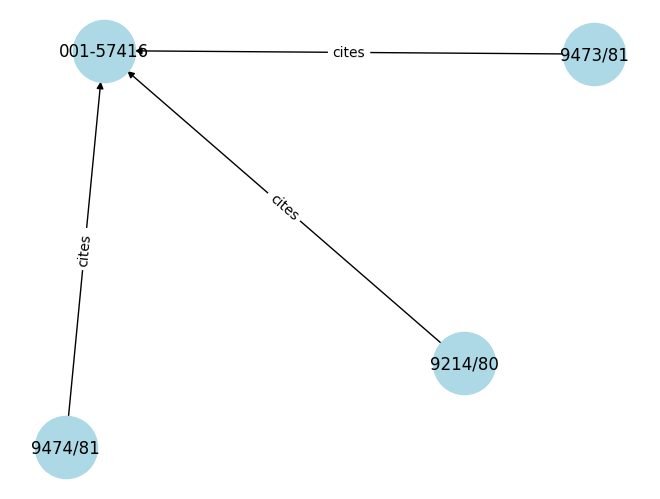

In [41]:
import matplotlib.pyplot as plt

def visualize_citation_network(itemid):
    subgraph_nodes = [itemid] + get_cited_applications(itemid)
    subgraph = G.subgraph(subgraph_nodes)

    pos = nx.spring_layout(subgraph)
    nx.draw(subgraph, pos, with_labels=True, node_size=2000, node_color="lightblue")
    labels = nx.get_edge_attributes(subgraph, "relationship")
    nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=labels)
    plt.show()

# Example usage
visualize_citation_network("001-57416")


In [46]:
def visualize_citation_network_with_styles(itemid, depth=3):
    # Get all nodes within the specified depth
    subgraph_nodes = nx.single_source_shortest_path_length(G, source=itemid, cutoff=depth).keys()
    subgraph = G.subgraph(subgraph_nodes)

    # Use Graphviz layout for better positioning
    pos = nx.nx_agraph.graphviz_layout(subgraph, prog="dot")

    # Prepare styles for nodes
    node_colors = []
    node_sizes = []
    for node in subgraph.nodes():
        node_data = G.nodes[node]
        if node_data["type"] == "Judgment":
            node_colors.append("lightblue")
            node_sizes.append(3000)
        elif node_data["type"] == "Application":
            node_colors.append("lightgreen")
            node_sizes.append(2000)
        elif node_data["type"] == "Article":
            node_colors.append("lightcoral")
            node_sizes.append(1000)
        else:
            node_colors.append("gray")
            node_sizes.append(1000)

    # Draw the graph
    plt.figure(figsize=(14, 10))
    nx.draw(
        subgraph, pos, with_labels=True, node_size=node_sizes, node_color=node_colors,
        font_size=10, font_weight="bold", edge_color="gray"
    )

    # Add edge labels
    edge_labels = nx.get_edge_attributes(subgraph, "relationship")
    nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=8)

    plt.title(f"Citation Network Visualization (Depth={depth})", fontsize=14)
    plt.show()

# Example usage
visualize_citation_network_with_styles("001-57416", depth=3)


ImportError: requires pygraphviz http://pygraphviz.github.io/

In [48]:
def analyze_citation_network(case_itemid):
    incoming = [
        source for source, target, data in G.edges(data=True)
        if target == case_itemid and data["relationship"] == "cites"
    ]
    outgoing = [
        target for source, target, data in G.edges(data=True)
        if source == case_itemid and data["relationship"] == "cites"
    ]
    return {"incoming": incoming, "outgoing": outgoing}

# Example usage
case_itemid = "001-220960"  # Replace with a key case ID
citation_network = analyze_citation_network(case_itemid)
print(f"Key Case {case_itemid} Citation Network:", citation_network)


Key Case 001-220960 Citation Network: {'incoming': ['34979/97', '66069/09', '41216/13', '72508/13', '38621/97', '42750/09', '22318/02', '28578/03', '57592/08', '21906/04', '2440/07', '8927/11', '30500/11', '43522/98', '31240/03', '25978/07', '5084/18', '498/10', '48058/09'], 'outgoing': []}


In [49]:
def compare_key_non_key_citation_patterns(importance_level="2"):
    key_cases = [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    ]
    non_key_cases = [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") != importance_level
    ]
    key_case_citations = sum(G.in_degree(node) for node in key_cases)
    non_key_case_citations = sum(G.in_degree(node) for node in non_key_cases)

    return {
        "key_case_avg_citations": key_case_citations / len(key_cases),
        "non_key_case_avg_citations": non_key_case_citations / len(non_key_cases),
    }

# Example usage
citation_comparison = compare_key_non_key_citation_patterns("2")
print("Citation comparison (Key vs Non-Key):", citation_comparison)


Citation comparison (Key vs Non-Key): {'key_case_avg_citations': 14.828395061728395, 'non_key_case_avg_citations': 16.255200837367525}


In [50]:
def find_clusters_of_key_cases(importance_level="2"):
    key_case_nodes = [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    ]
    subgraph = G.subgraph(key_case_nodes)
    clusters = list(nx.connected_components(subgraph.to_undirected()))
    return clusters

# Example usage
key_case_clusters = find_clusters_of_key_cases("1")
print("Key case clusters:", key_case_clusters)


Key case clusters: [{'001-60495'}, {'001-58978'}, {'001-88429'}, {'001-58833'}, {'001-58561'}, {'001-59625'}, {'001-207360'}, {'001-61169'}, {'001-97704'}, {'001-68373'}, {'001-91706'}, {'001-183395'}, {'001-181591'}, {'001-58304'}, {'001-60532'}, {'001-206153'}, {'001-81356'}, {'001-75137'}, {'001-61829'}, {'001-61207'}, {'001-105691'}, {'001-158290'}, {'001-61962'}, {'001-192210'}, {'001-58751'}, {'001-104685'}, {'001-194618'}, {'001-61686'}, {'001-60877'}, {'001-60417'}, {'001-184525'}, {'001-189781'}, {'001-72893'}, {'001-60750'}, {'001-118477'}, {'001-60723'}, {'001-77785'}, {'001-200344'}, {'001-61142'}, {'001-179556'}, {'001-94162'}, {'001-70293'}, {'001-101739'}, {'001-59455'}, {'001-59221'}, {'001-206369'}, {'001-61185'}, {'001-68790'}, {'001-87404'}, {'001-76307'}, {'001-192616'}, {'001-72055'}, {'001-219333'}, {'001-164928'}, {'001-71594'}, {'001-58251'}, {'001-118276'}, {'001-203165'}, {'001-59051'}, {'001-58461'}, {'001-60174'}, {'001-145442'}, {'001-77932'}, {'001-93475'}

In [52]:
def compute_centrality_of_key_cases(importance_level="2"):
    centrality = nx.degree_centrality(G)
    key_case_centrality = {
        node: centrality[node]
        for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    }
    return sorted(key_case_centrality.items(), key=lambda x: x[1], reverse=True)

# Example usage
key_case_centrality = compute_centrality_of_key_cases("1")
print("Key case centrality:", key_case_centrality)


Key case centrality: [('001-179556', 0.003449383440166464), ('001-182243', 0.0030723253313223566), ('001-178753', 0.0028768137193291156), ('001-175646', 0.0028349183739019928), ('001-145575', 0.002681302107335875), ('001-207757', 0.0024438951499155107), ('001-184525', 0.0024438951499155107), ('001-207173', 0.002290278883349393), ('001-187540', 0.0021506277319256494), ('001-127684', 0.002122697501640901), ('001-170054', 0.0020947672713561524), ('001-194307', 0.0020249416956442806), ('001-158235', 0.0020249416956442806), ('001-111634', 0.0018154649685086653), ('001-146540', 0.0018014998533662909), ('001-164515', 0.001731674277654419), ('001-187605', 0.0017177091625120448), ('001-109868', 0.0017177091625120448), ('001-165032', 0.0017177091625120448), ('001-145577', 0.0015780580110883013), ('001-145546', 0.0015780580110883013), ('001-187932', 0.0015501277808035526), ('001-168972', 0.0015361626656611783), ('001-171804', 0.0015082324353764295), ('001-122716', 0.0014942673202340553), ('001-20

In [53]:
def compute_centrality_of_key_cases(importance_level="2"):
    centrality = nx.degree_centrality(G)
    key_case_centrality = {
        node: centrality[node]
        for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    }
    return sorted(key_case_centrality.items(), key=lambda x: x[1], reverse=True)

# Example usage
key_case_centrality = compute_centrality_of_key_cases("4")
print("Key case centrality:", key_case_centrality)


Key case centrality: [('001-151005', 0.014398033711787953), ('001-177393', 0.01191224321644532), ('001-145780', 0.0037845462035834485), ('001-138921', 0.003770581088441074), ('001-139906', 0.0037426508581563252), ('001-138918', 0.003686790397586828), ('001-123391', 0.0036728252824444535), ('001-140783', 0.003658860167302079), ('001-121828', 0.003644895052159705), ('001-122434', 0.0036029997067325817), ('001-140782', 0.0036029997067325817), ('001-119967', 0.002806988143617244), ('001-96387', 0.002765092798190121), ('001-121827', 0.0023880346893460137), ('001-219983', 0.00192718588964766), ('001-225765', 0.0019132207745052856), ('001-116758', 0.0018573603139357883), ('001-84533', 0.0017735696230815423), ('001-115885', 0.0017596045079391678), ('001-112414', 0.0017037440473696706), ('001-174615', 0.0016618487019425475), ('001-178357', 0.00160598824137305), ('001-95089', 0.0015920231262306758), ('001-115304', 0.0015780580110883013), ('001-219044', 0.0015780580110883013), ('001-118732', 0.00

In [54]:
from datetime import datetime

def key_cases_over_time(importance_level="2"):
    time_series = {}
    for node, data in G.nodes(data=True):
        if data["type"] == "Judgment" and data.get("importance") == importance_level:
            year = datetime.strptime(data["judgementdate"], "%d/%m/%Y").year
            time_series[year] = time_series.get(year, 0) + 1
    return time_series

# Example usage
key_case_trends = key_cases_over_time("1")
print("Key cases over time:", key_case_trends)


Key cases over time: {2002: 63, 2016: 27, 2001: 72, 2005: 57, 1999: 50, 2010: 25, 2017: 27, 2018: 26, 2015: 29, 2007: 26, 2006: 86, 2004: 55, 2000: 86, 2019: 15, 2003: 74, 2014: 22, 2008: 27, 2012: 30, 2021: 22, 2013: 25, 2009: 27, 2022: 7, 2011: 28, 2020: 25, 1996: 1}


In [55]:
def compare_outgoing_citations(importance_level="2"):
    key_cases = [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") == importance_level
    ]
    key_outgoing = sum(len(G[node]) for node in key_cases)

    non_key_cases = [
        node for node, data in G.nodes(data=True)
        if data["type"] == "Judgment" and data.get("importance") != importance_level
    ]
    non_key_outgoing = sum(len(G[node]) for node in non_key_cases)

    return {
        "key_case_avg_outgoing": key_outgoing / len(key_cases),
        "non_key_case_avg_outgoing": non_key_outgoing / len(non_key_cases),
    }

# Example usage
outgoing_comparison = compare_outgoing_citations("1")
print("Outgoing citation comparison (Key vs Non-Key):", outgoing_comparison)


Outgoing citation comparison (Key vs Non-Key): {'key_case_avg_outgoing': 3.3776824034334765, 'non_key_case_avg_outgoing': 2.206343972566605}
